In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# Load the cleaned dataset
df = pd.read_csv('emi_prediction_cleaned.csv')

In [3]:
print("Dataset loaded successfully!")
print("Shape:", df.shape) 

Dataset loaded successfully!
Shape: (388233, 27)


In [4]:
# Basic overview
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Name:")
print(df.columns.tolist())

Rows: 388233
Columns: 27

Column Name:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'emi_eligibility', 'max_monthly_emi']


In [5]:
# Data Types
print(df.dtypes)

age                       float64
gender                     object
marital_status             object
education                  object
monthly_salary            float64
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object


In [6]:
numerical_columns = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "max_monthly_emi"
]

In [7]:
categorical_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "company_type",
    "house_type",
    "existing_loans",
    "bank_balance",
    "emi_scenario",
    "emi_eligibility"
]

In [8]:
# Missing Values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [9]:
# Duplicate Check
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [10]:
# Statistical Summary
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,388233.0,38.879511,9.301626,26.0,32.0,38.00,48.0,59.0
monthly_salary,388233.0,59507.074700,43380.148137,3967.0,35400.0,51700.00,73000.0,499970.0
years_of_employment,388233.0,5.370930,6.087006,0.5,1.2,3.20,7.2,36.0
monthly_rent,388233.0,5830.243575,8648.138787,0.0,0.0,0.00,10600.0,80000.0
family_size,388233.0,2.941110,1.075098,1.0,2.0,3.00,4.0,5.0
dependents,388233.0,1.941110,1.075098,0.0,1.0,2.00,3.0,4.0
school_fees,388233.0,4625.229695,5061.387432,0.0,0.0,3000.00,9000.0,15000.0
college_fees,388233.0,4067.514611,7320.551029,0.0,0.0,0.00,6500.0,25000.0
travel_expenses,388233.0,5687.083272,3391.912235,600.0,3200.0,4900.00,7400.0,30300.0
groceries_utilities,388233.0,12806.037611,6992.172074,1800.0,7700.0,11400.00,16400.0,71200.0


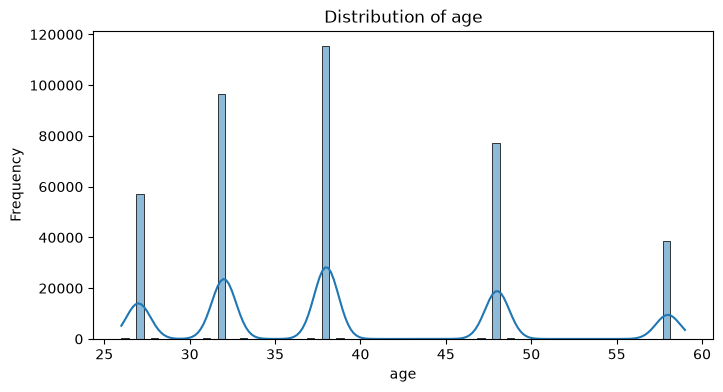

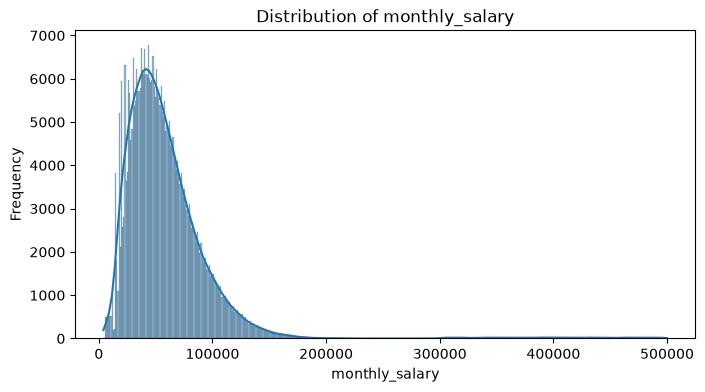

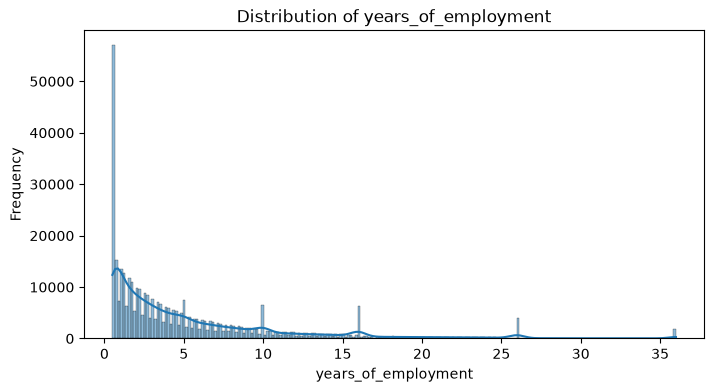

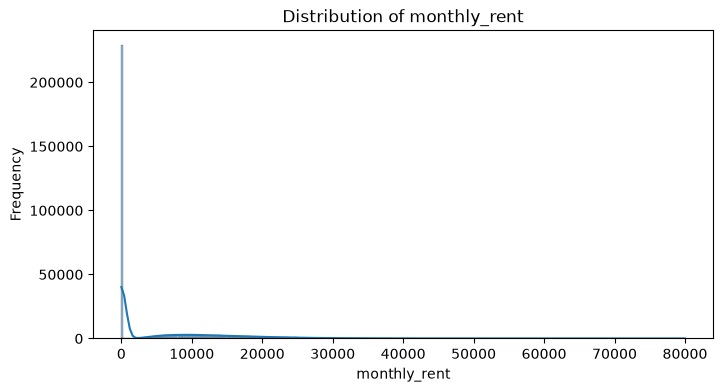

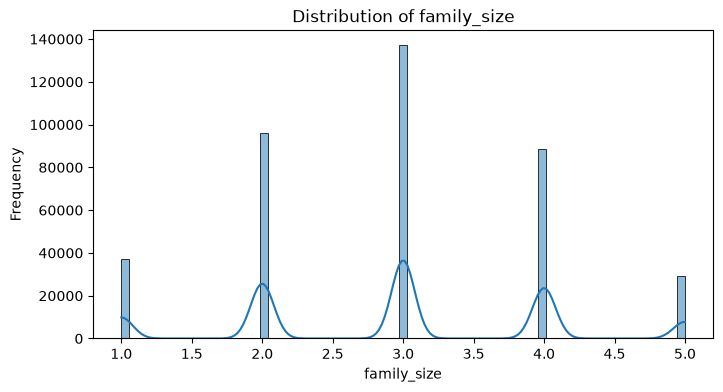

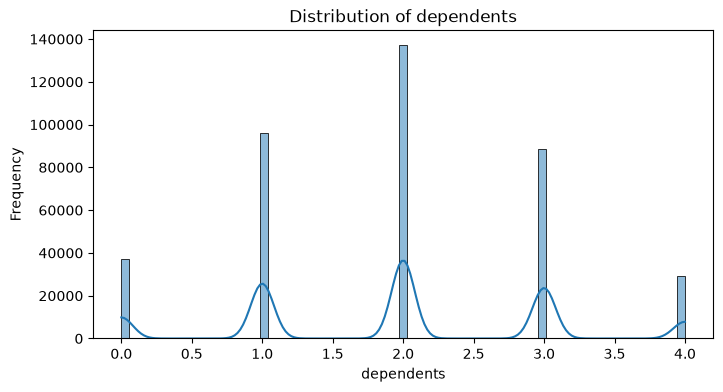

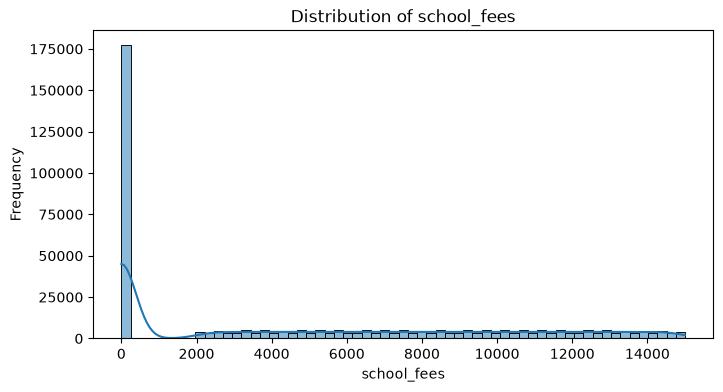

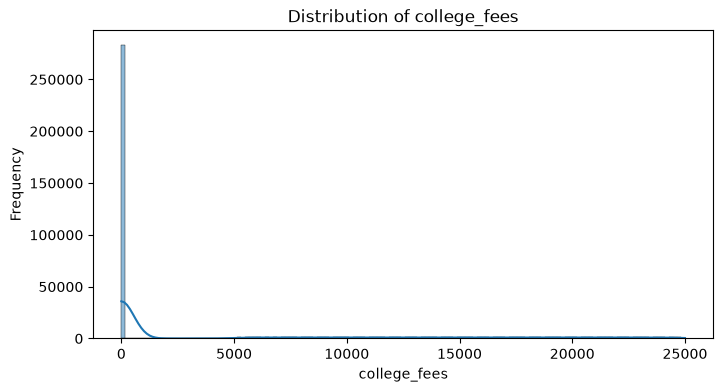

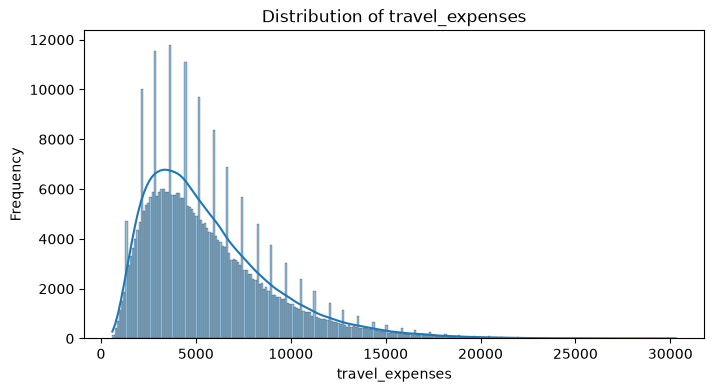

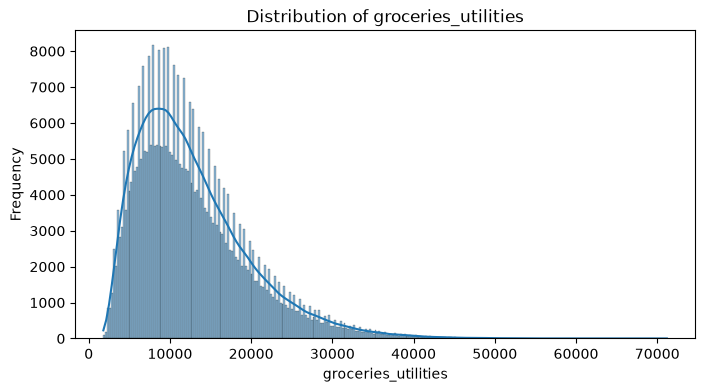

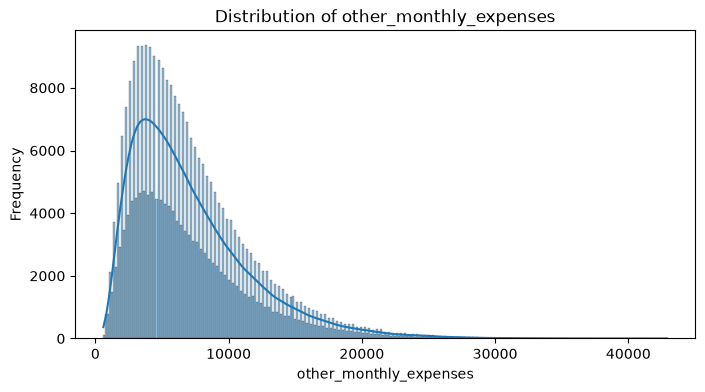

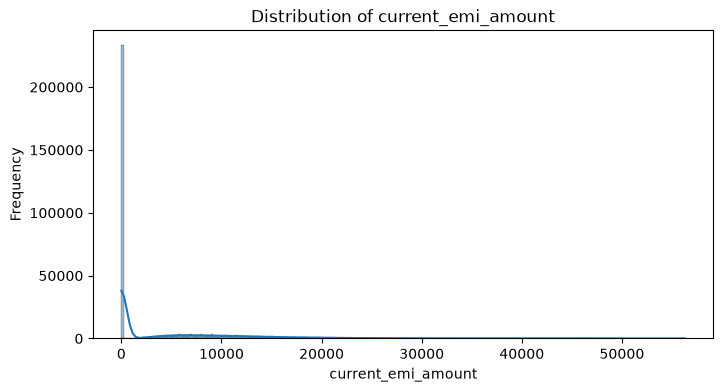

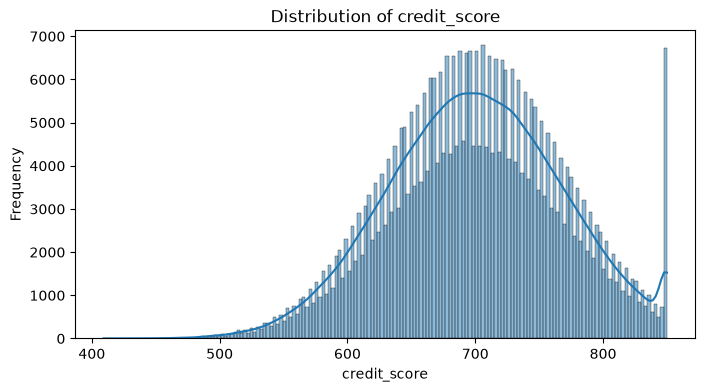

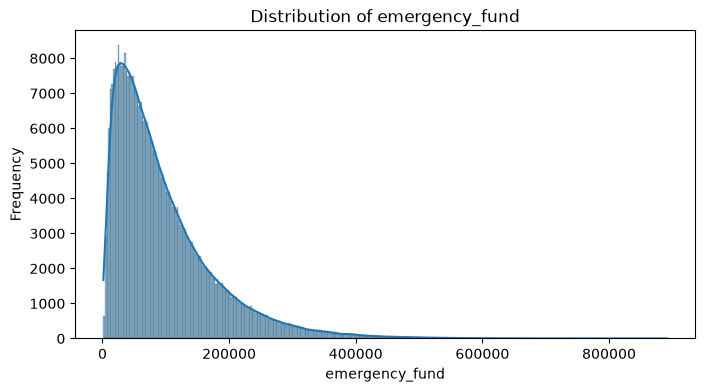

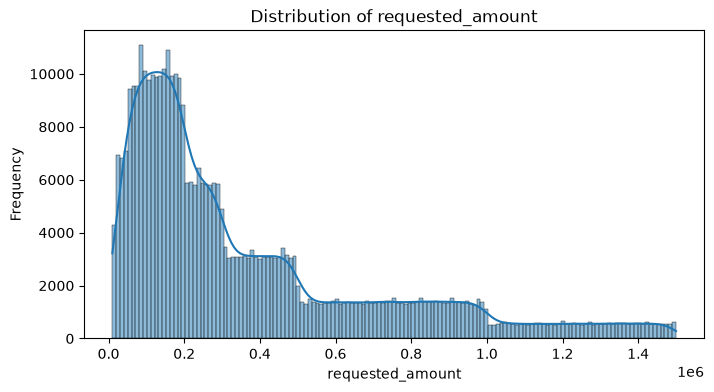

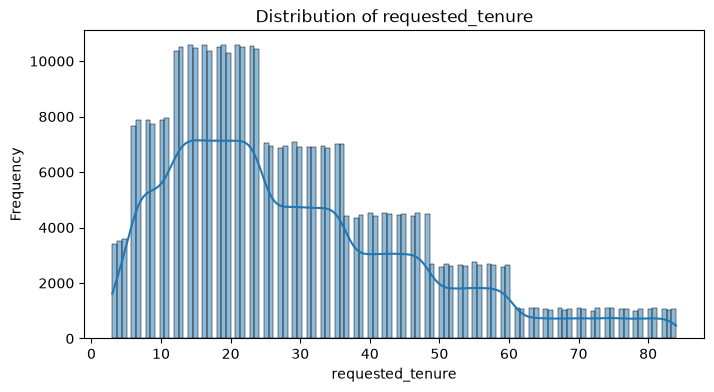

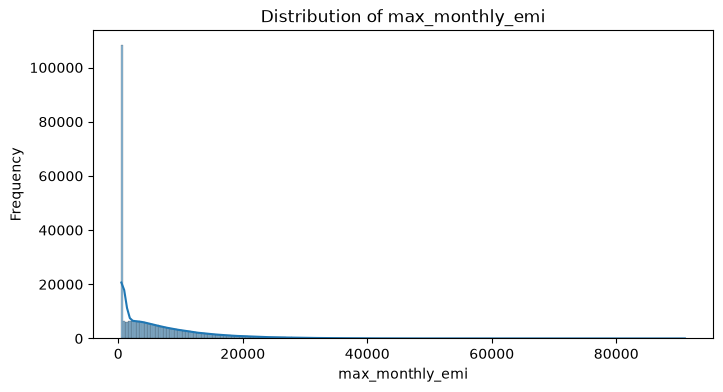

In [11]:
# Numerical Distributins
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

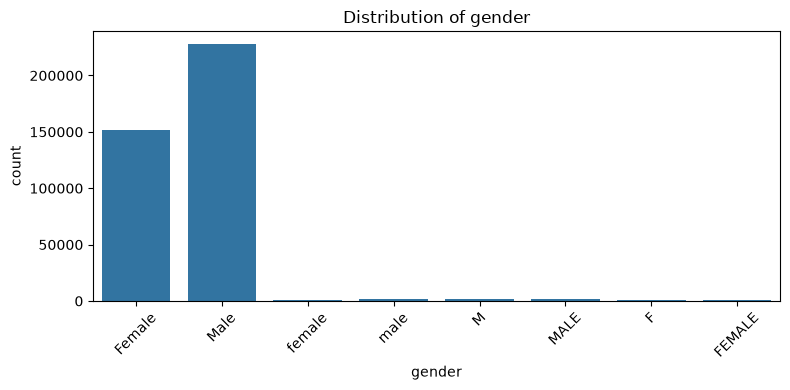

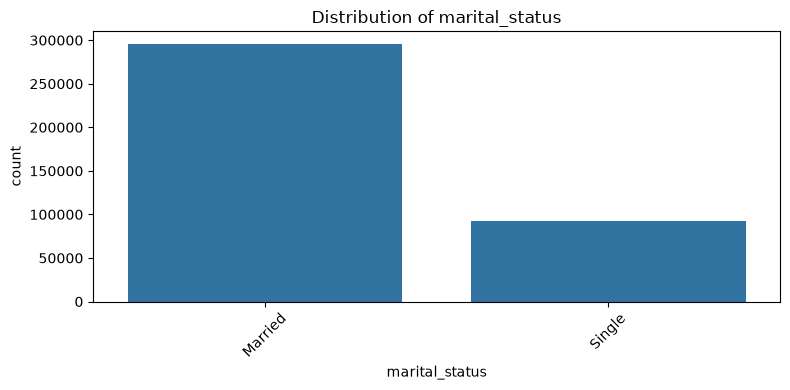

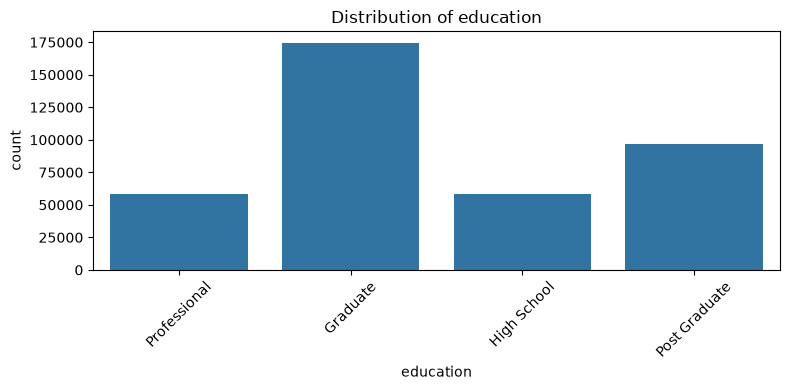

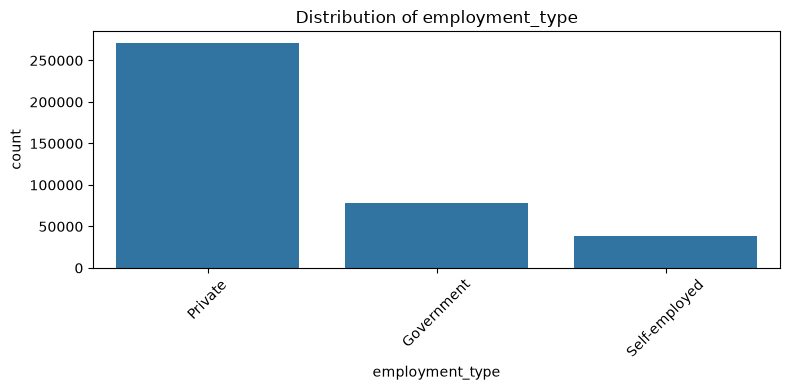

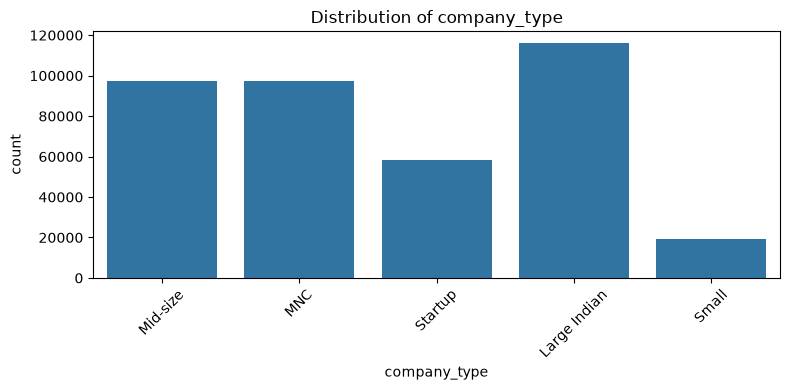

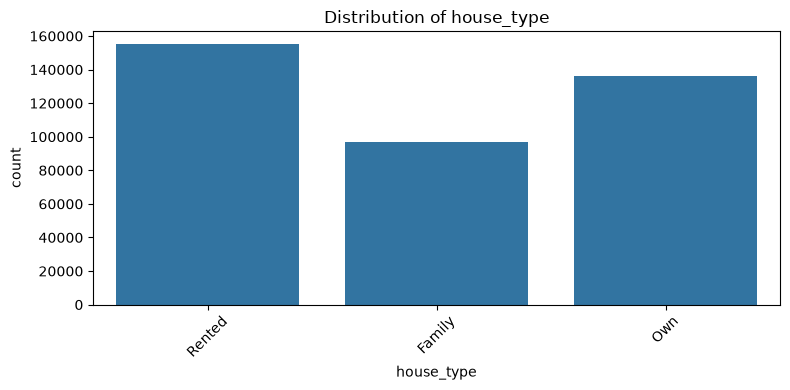

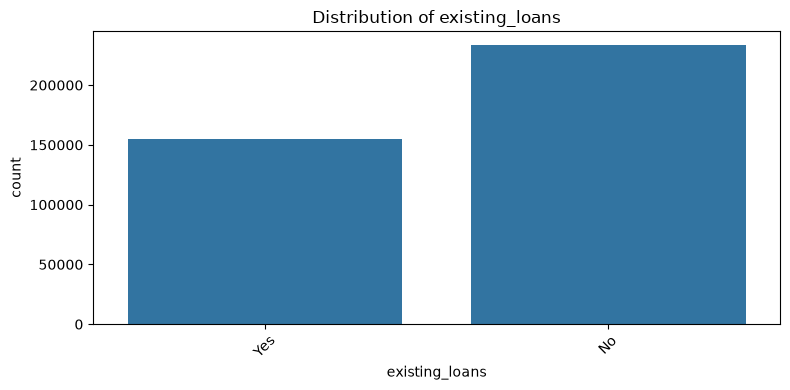

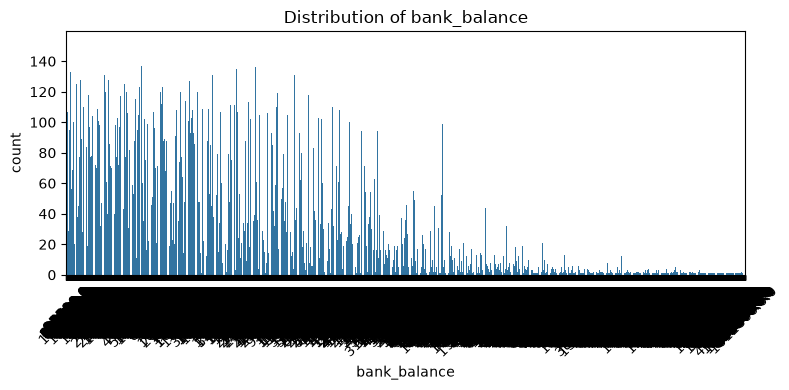

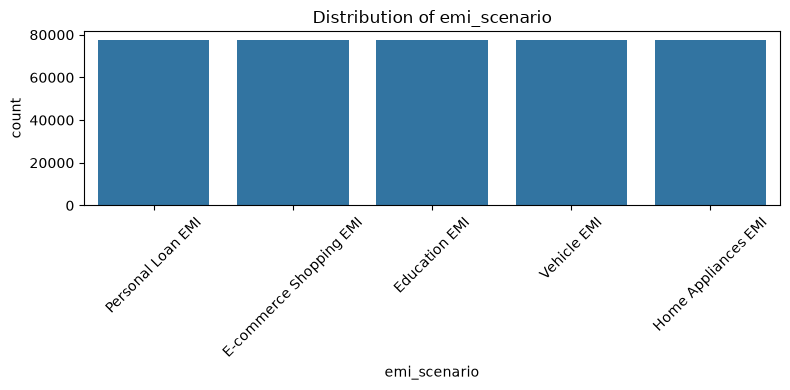

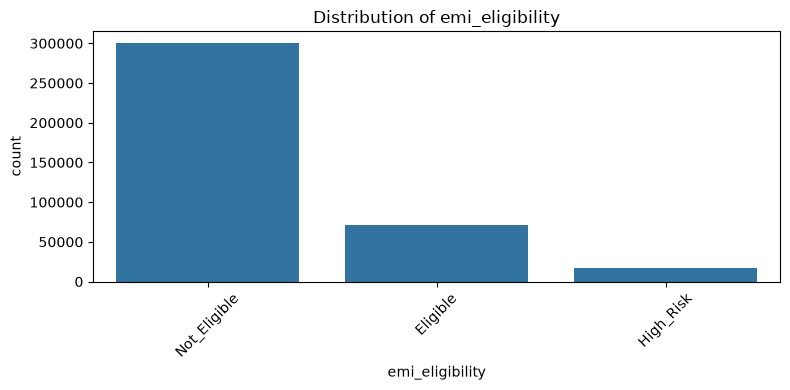

In [12]:
# Categorical Distributions
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

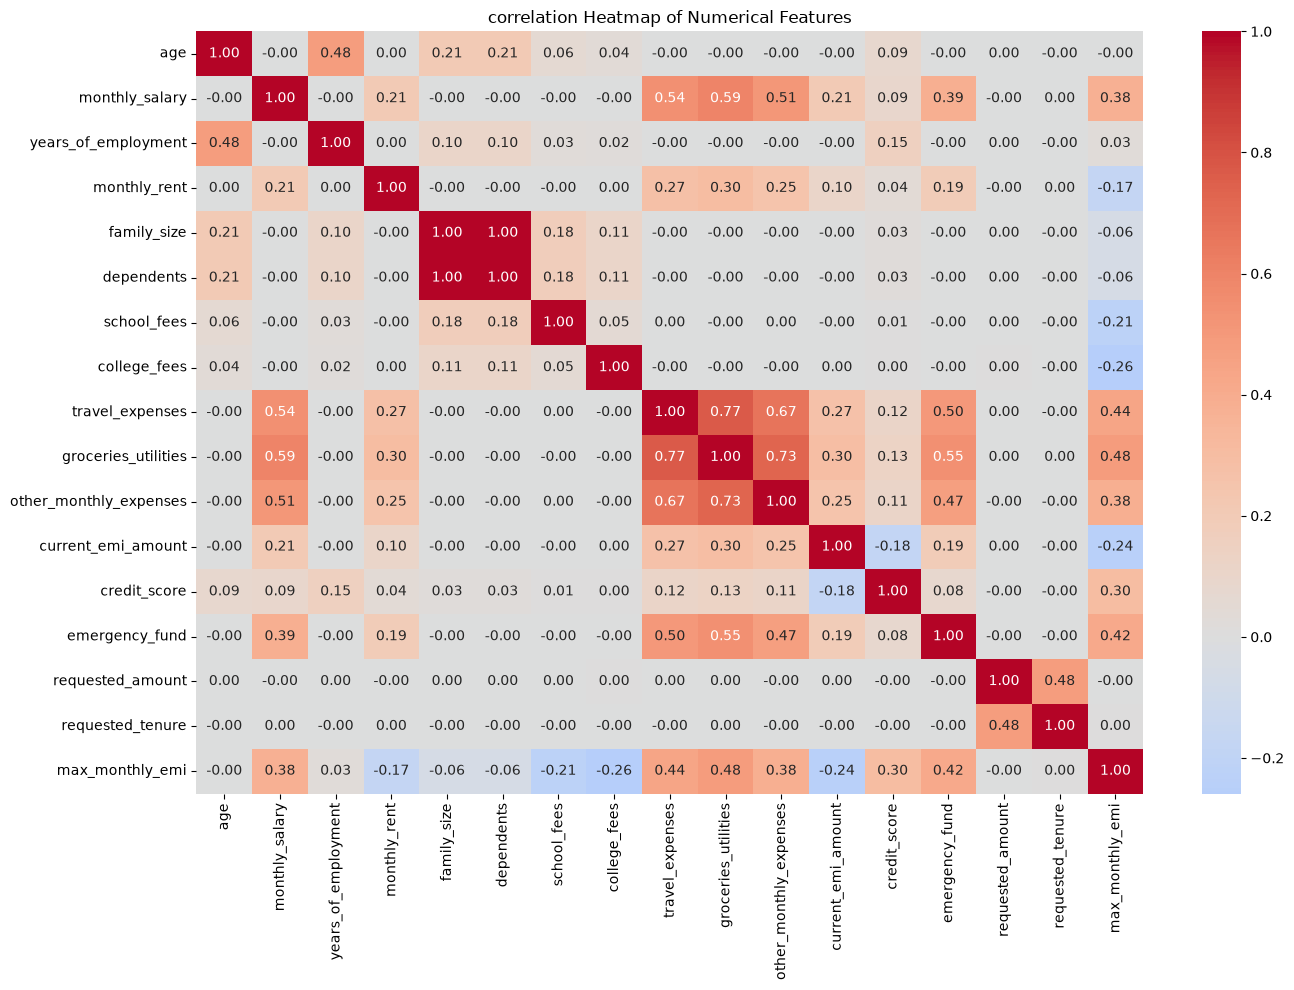

In [13]:
# Correlation heatmap

plt.figure(figsize=(14, 10))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

 This is one of the most important EDA visualizations because it helpes us identify relations between variables. 

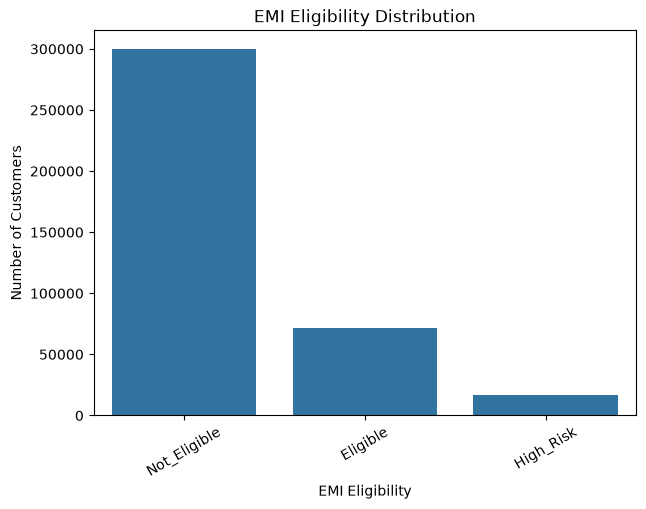

In [14]:
# emi eligibility distribution

plt.figure(figsize=(7,5))

sns.countplot(data=df, x='emi_eligibility')

plt.title("EMI Eligibility Distribution")
plt.xlabel("EMI Eligibility")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

In [15]:
# Outlier analysis using IQR
outlier_summary =[]

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].sum()

    outlier_count = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outlier_count,
        "Outliers %": round((outlier_count / len(df)) * 100, 2)
    })

outliers_df = pd.DataFrame(outlier_summary)
outliers_df 


,Column,Q1,Q3,Lower Bound,Upper Bound,Outliers,Outliers %
0,age,32.0,48.0,8.0,72.0,0,0.00
1,monthly_salary,35400.0,73000.0,-21000.0,129400.0,11604,2.99
2,years_of_employment,1.2,7.2,-7.8,16.2,22046,5.68
3,monthly_rent,0.0,10600.0,-15900.0,26500.0,12248,3.15
4,family_size,2.0,4.0,-1.0,7.0,0,0.00
5,dependents,1.0,3.0,-2.0,6.0,0,0.00
6,school_fees,0.0,9000.0,-13500.0,22500.0,0,0.00
7,college_fees,0.0,6500.0,-9750.0,16250.0,46053,11.86
8,travel_expenses,3200.0,7400.0,-3100.0,13700.0,11945,3.08
9,groceries_utilities,7700.0,16400.0,-5350.0,29450.0,11288,2.91


# this will give us a table showing how many outliers each numerical feature has.

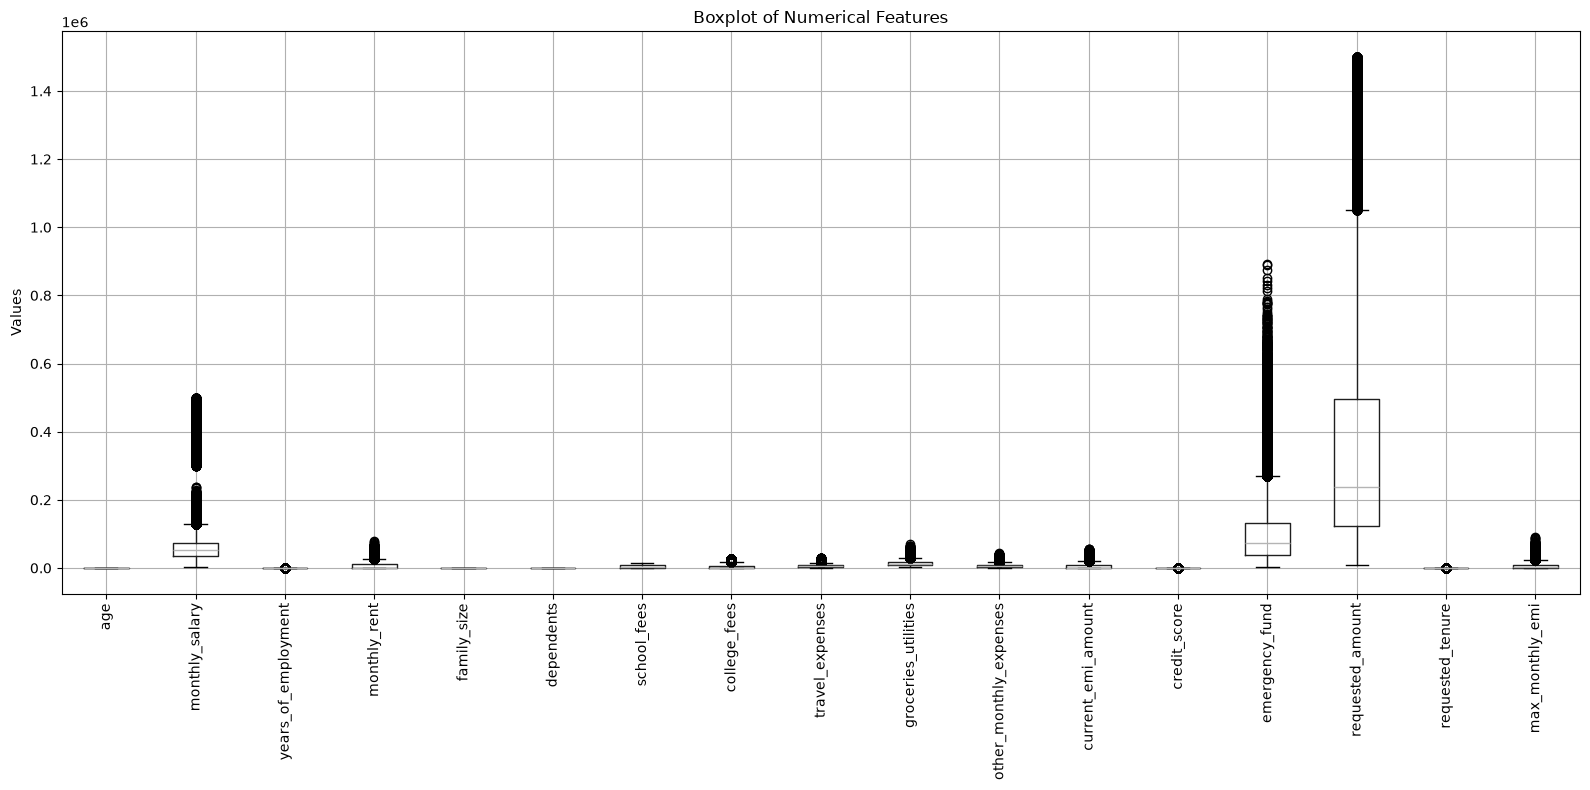

In [16]:
# visualization of outliers using boxplots

plt.figure(figsize=(16, 8))

df[numerical_columns].boxplot(rot=90)

plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.tight_layout()        
plt.show()                    

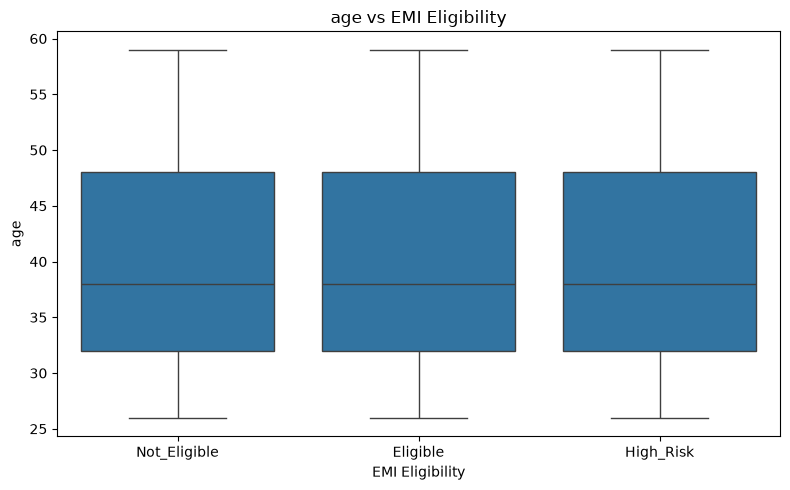

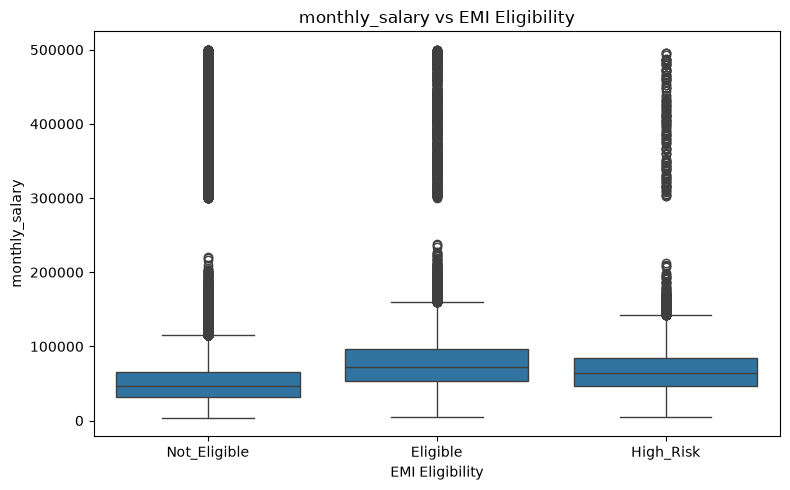

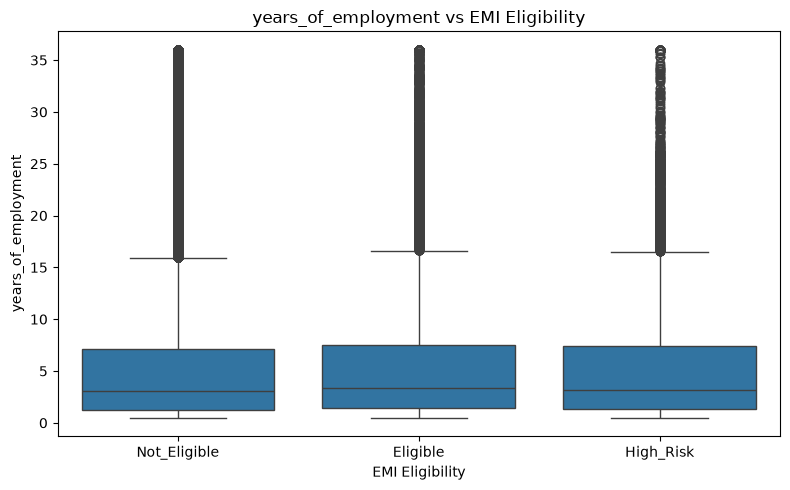

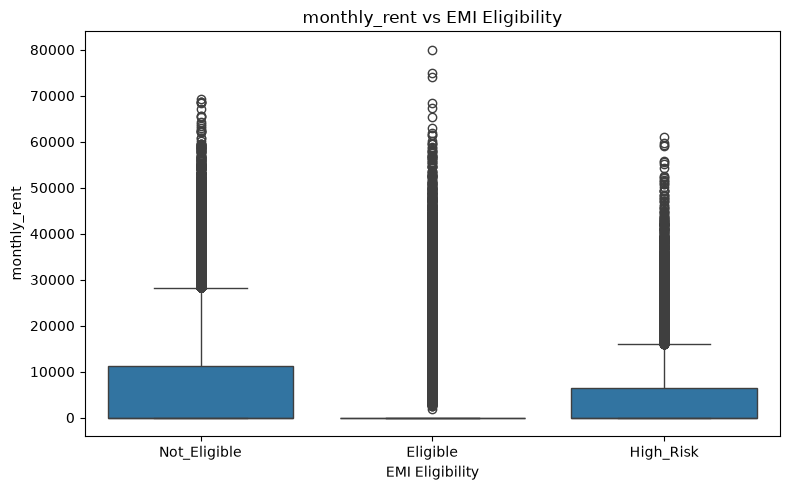

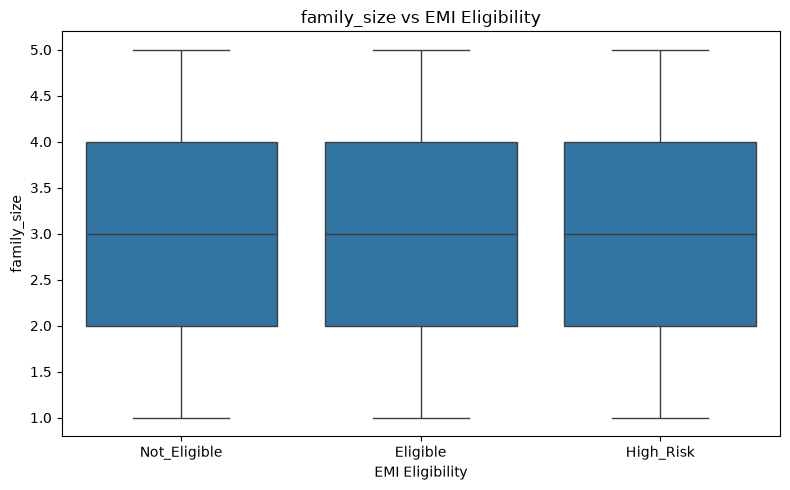

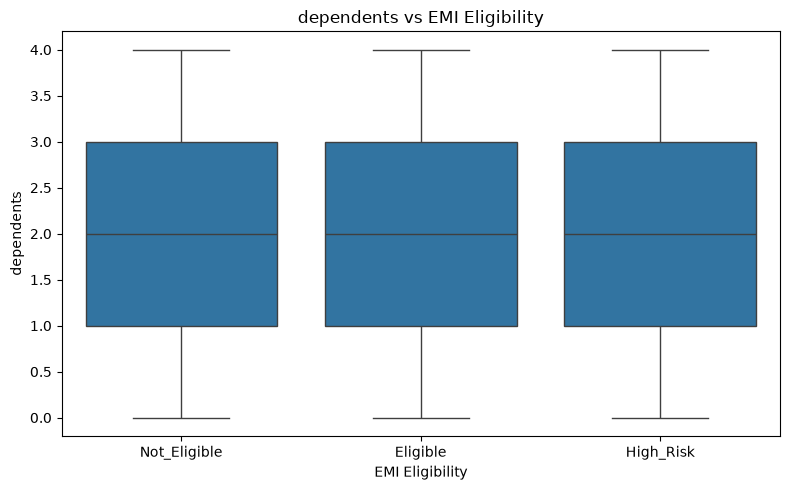

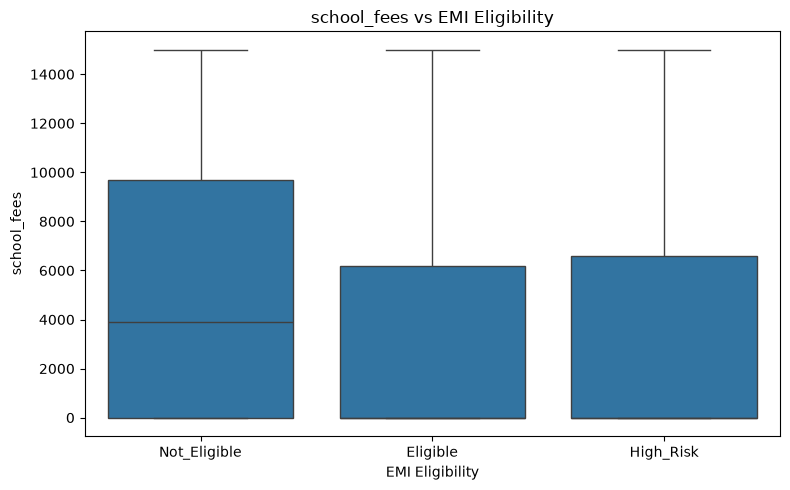

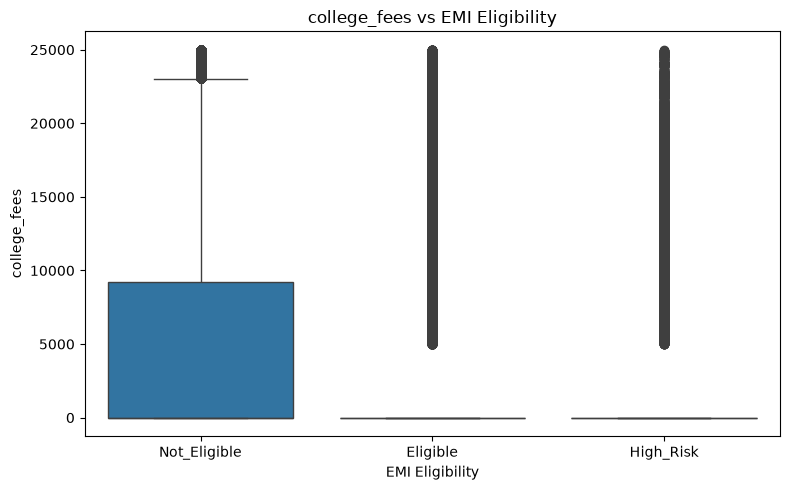

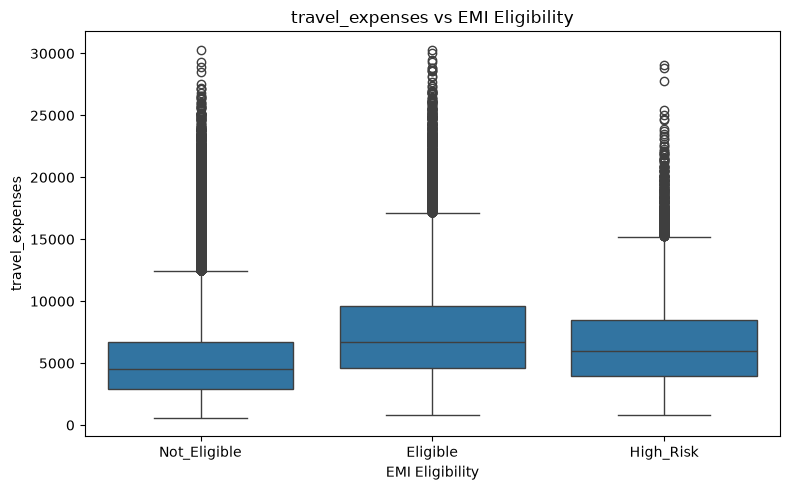

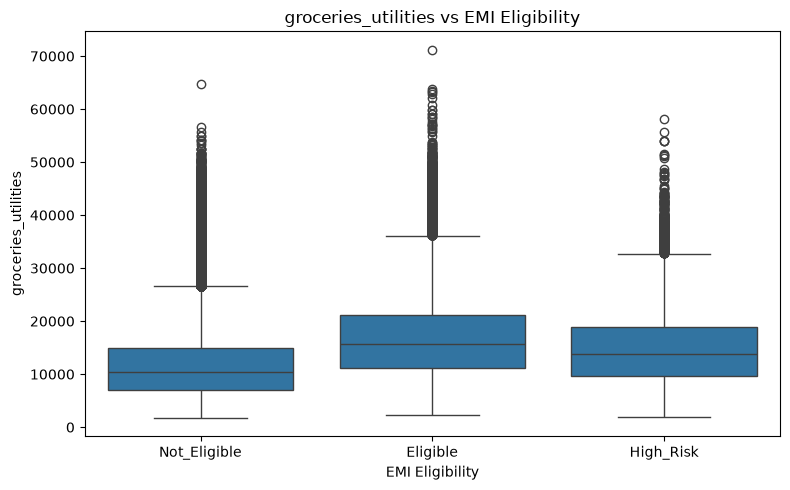

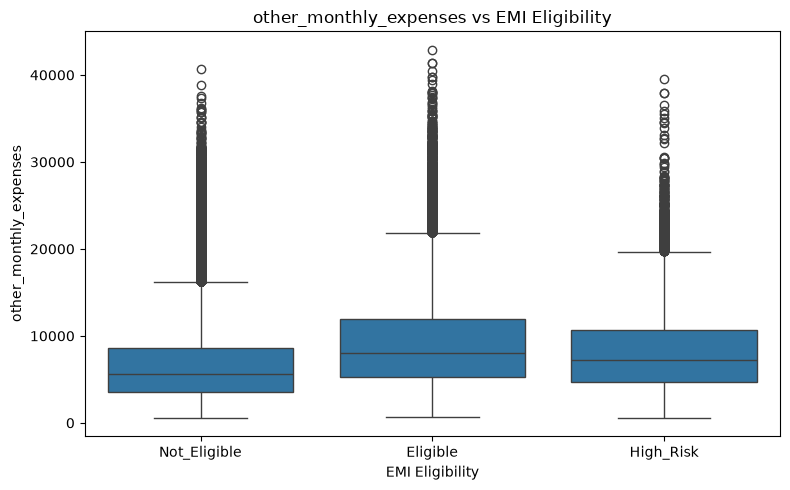

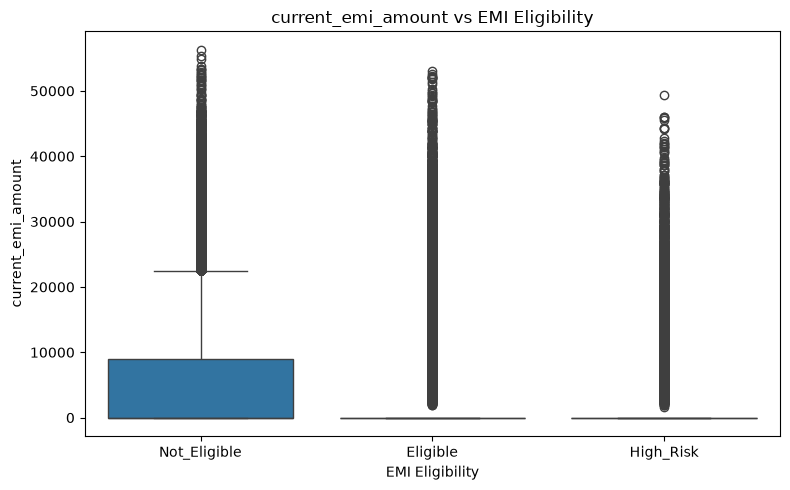

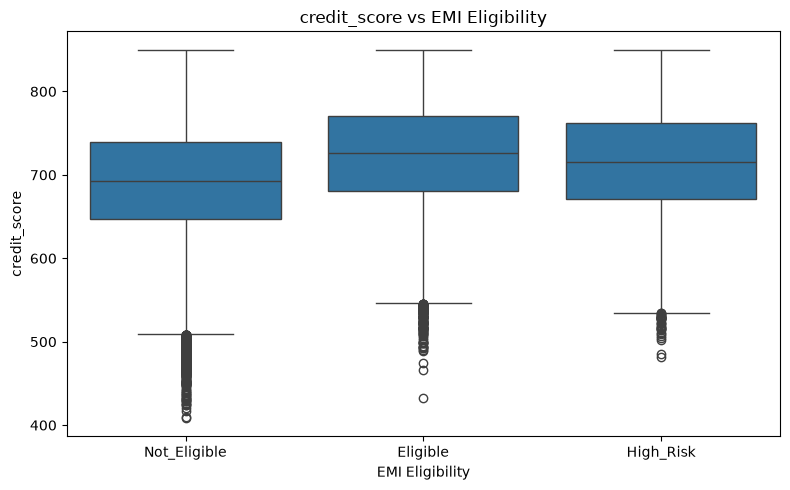

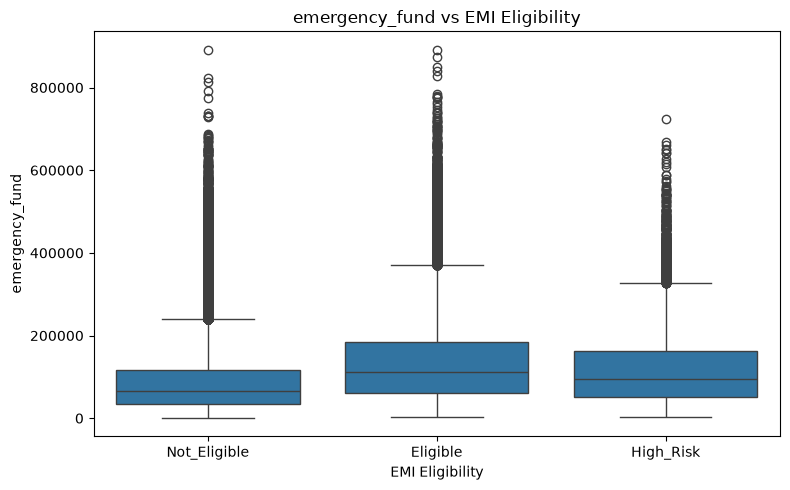

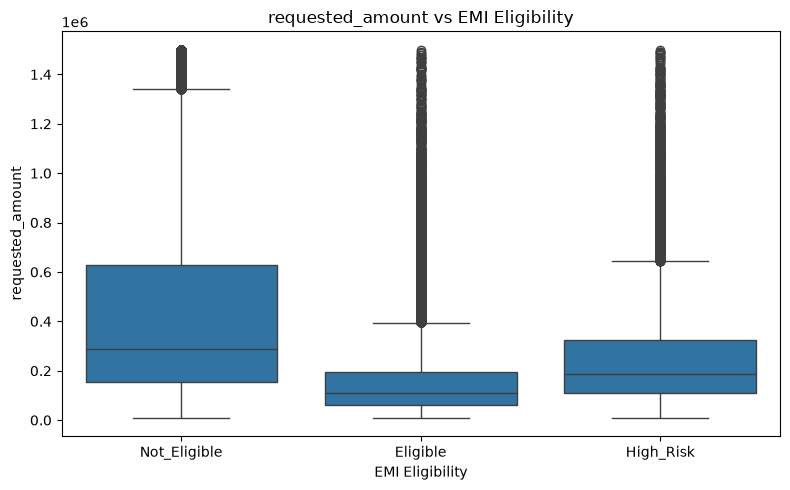

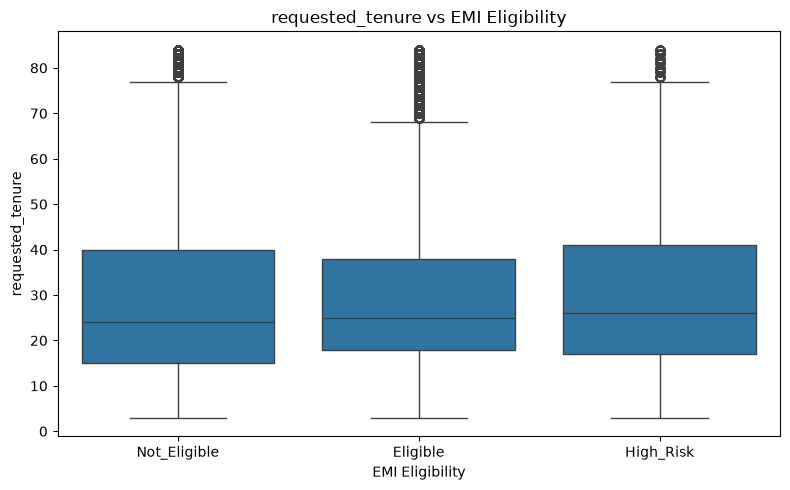

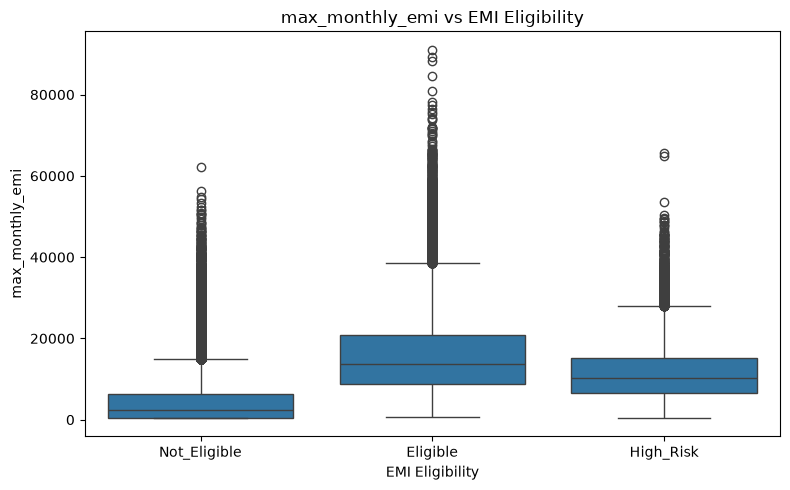

In [20]:
# Numerical Features Vs EMI Eligibility
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='emi_eligibility', y=col, data=df)

    plt.title(f"{col} vs EMI Eligibility")
    plt.xlabel("EMI Eligibility")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## EDA Summary

### Key Findings

- The dataset contains 388,233 records and 27 features.

- Numerical features include demographic, employment, financial, credit, and loan-related variables.

- Categorical features include gender, marital status, education, employment type, company type, house type, existing loans, bank balance, EMI scenario, and EMI eligibility.

- No significant missing-value issues were identified after data cleaning.

- Outlier analysis was performed using the IQR method and boxplots.

- Correlation analysis was performed using a numerical-feature heatmap.

- The distribution of EMI eligibility was analyzed to understand the target classes.

- Feature relationships with EMI eligibility were explored using numerical and categorical visualizations.